# Activity Sample EDA
Explores developer engagement patterns and lead/campaign source distributions.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

In [71]:
# Load sample CSVs
DATA_DIR = Path('Data')

activity_df = pd.read_csv(DATA_DIR / 'activity_sample.csv', low_memory=False)
contact_df  = pd.read_csv(DATA_DIR / 'contact_sample.csv',  low_memory=False)

print('Activity shape:', activity_df.shape)
print('Contact shape: ', contact_df.shape)

Activity shape: (100000, 16)
Contact shape:  (100000, 32)


In [72]:
# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

Data Overview

In [73]:
display(activity_df.head(3))
print('Column dtypes:')
display(activity_df.dtypes)
print('Null counts:')
display(activity_df.isnull().sum())

,dev_contact,activity,activity_name,activity_type,activity_role,activity_attendance,activity_score,activity_date,activity_id,filepath,pk1,pk2,lead_source,nvidia_campaign_id,gtc_nvidia_campaign_id,lead_source_details
0,1204149,DevZone Downloads,JetPack,Installer,Devzone,NaN,3.0,2020-10-03 00:00:00,2399744_894274_20201003,verizon://assets/embedded/secure/tools/files/j...,2399744_894274_20201003,894274,NaN,NaN,NaN,NaN
1,5881636,DevZone Downloads,jetpack,Installer,Devzone,NaN,3.0,2021-03-10 00:00:00,1000045_896923_20210310,verizon://assets/embedded/secure/tools/files/j...,1000045_896923_20210310,896923,NaN,NaN,NaN,NaN
2,5903679,NGC Downloads,Triton Inference Server,Container,NGC,NaN,5.0,2025-07-01 00:00:00,mevp3k1j5ouevcb14rat9di4r5_d5685261d42a6a71475...,nvidia/tritonserver:23.03-pyt-python-py3,mevp3k1j5ouevcb14rat9di4r5_d5685261d42a6a71475...,d5685261d42a6a71475d8b6d09133ebf,NaN,NaN,NaN,NaN


Column dtypes:


dev_contact                object
activity                   object
activity_name              object
activity_type              object
activity_role              object
activity_attendance        object
activity_score            float64
activity_date              object
activity_id                object
filepath                   object
pk1                        object
pk2                        object
lead_source                object
nvidia_campaign_id         object
gtc_nvidia_campaign_id     object
lead_source_details        object
dtype: object

Null counts:


dev_contact                   0
activity                      0
activity_name              7117
activity_type                 0
activity_role             13250
activity_attendance       81475
activity_score             1290
activity_date                 0
activity_id                   0
filepath                  22076
pk1                           0
pk2                         162
lead_source               82972
nvidia_campaign_id        99025
gtc_nvidia_campaign_id    99999
lead_source_details       84166
dtype: int64

In [74]:
# Contact Sample
display(contact_df.head(3))
print('Null counts:')
display(contact_df.isnull().sum())

,developer_id,program_application_source,country,region,sub_region,zone,territory,organization_english_name,development_areas,other_development_areas,industry_segment_vertical,other_industry_segment_vertical,sub_industry_segment_vertical,fields_of_interest,other_fields_of_interest,first_program_application_date,account_id,account_name,last_activity_date,last_modified_date,created_date,wwfo_category,wwfo_target_list,account_industry_segment,account_source,account_type,devzone_last_login_date,organization_website,inception_id,first_activity_date,normalized_account_name,rdp_exit_date
0,9596620,devzone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN,7704,Unclassified - Invalid,NaN,2025-10-03 06:55:00.302,2025-10-03 06:55:00.302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unclassified - Invalid,NaN
1,6413764,devzone,Thailand,APAC,ROAP,SEA,NaN,Arkhbum,Data Science;Edge Computing;Content Creation /...,NaN,Manufacturing,NaN,NaN,NaN,NaN,2025-11-08 04:54:31,31153,Not Normalized,2025-11-14 00:00:00,2025-11-08 04:54:58.042,2024-03-25 12:25:33.931,NaN,NaN,NaN,Manual,NaN,2025-11-07 20:54:31,NaN,NaN,2024-03-25 12:06:06,Not Normalized,NaN
2,6479893,devzone,United States,NALA,US & Canada,US & Canada,NaN,renraku,AR / VR;Other,NaN,Other,music,NaN,NaN,NaN,2024-03-25 03:24:58,31153,Not Normalized,2024-03-25 03:24:58,2024-03-25 03:55:02.058,2024-03-25 03:24:59.467,NaN,NaN,NaN,Manual,NaN,2024-03-24 20:25:06,NaN,NaN,2024-03-25 00:00:00,Not Normalized,NaN


Null counts:


developer_id                            0
program_application_source          45098
country                              8894
region                               8894
sub_region                           8894
zone                                 8894
territory                           60811
organization_english_name           21058
development_areas                   20272
other_development_areas             94743
industry_segment_vertical               0
other_industry_segment_vertical     84741
sub_industry_segment_vertical       96266
fields_of_interest                 100000
other_fields_of_interest           100000
first_program_application_date      29041
account_id                              0
account_name                            0
last_activity_date                  17901
last_modified_date                      0
created_date                            0
wwfo_category                       86638
wwfo_target_list                    81441
account_industry_segment          

Clean

In [75]:
# Parse activity_date
activity_df['activity_date'] = pd.to_datetime(activity_df['activity_date'], errors='coerce')
activity_df['year']  = activity_df['activity_date'].dt.year
activity_df['month'] = activity_df['activity_date'].dt.to_period('M')
activity_df['dow']   = activity_df['activity_date'].dt.day_name()

# Normalize string columns
for col in ['activity_type', 'activity_role', 'lead_source', 'activity_name']:
    if col in activity_df.columns:
        activity_df[col] = activity_df[col].astype(str).str.strip().str.title()

# Numeric score
activity_df['activity_score'] = pd.to_numeric(activity_df['activity_score'], errors='coerce')

print('Date range:', activity_df['activity_date'].min(), 'to', activity_df['activity_date'].max())
print('Unique developers:', activity_df['dev_contact'].nunique())

Date range: 2020-01-01 00:00:00 to 2026-03-12 15:56:17
Unique developers: 80054


Engagement volume over time

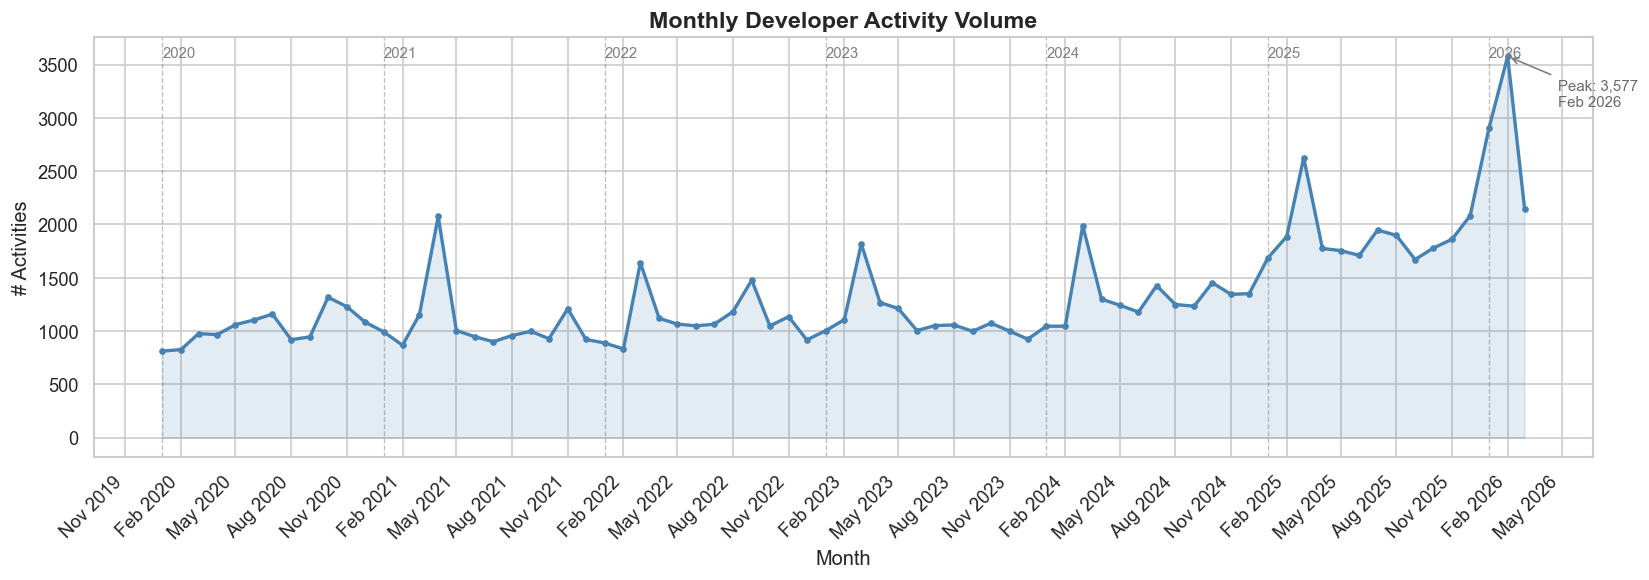

In [76]:
monthly = activity_df.groupby('month').size().reset_index(name='activity_count')
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))

# Line + shaded area
ax.fill_between(monthly['month_dt'], monthly['activity_count'], alpha=0.15, color='steelblue')
ax.plot(monthly['month_dt'], monthly['activity_count'], color='steelblue', linewidth=2, marker='o', markersize=3)

# Add year dividers
for year in monthly['month_dt'].dt.year.unique():
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1]*0.95, str(year),
            fontsize=9, color='gray', ha='left')

# Highlight peak month
peak_idx = monthly['activity_count'].idxmax()
peak_row = monthly.loc[peak_idx]
ax.annotate(f"Peak: {peak_row['activity_count']:,}\n{peak_row['month_dt'].strftime('%b %Y')}",
            xy=(peak_row['month_dt'], peak_row['activity_count']),
            xytext=(30, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='dimgray')

ax.set_title('Monthly Developer Activity Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('# Activities')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Activity Type Distribution

<positron-console-cell-77>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



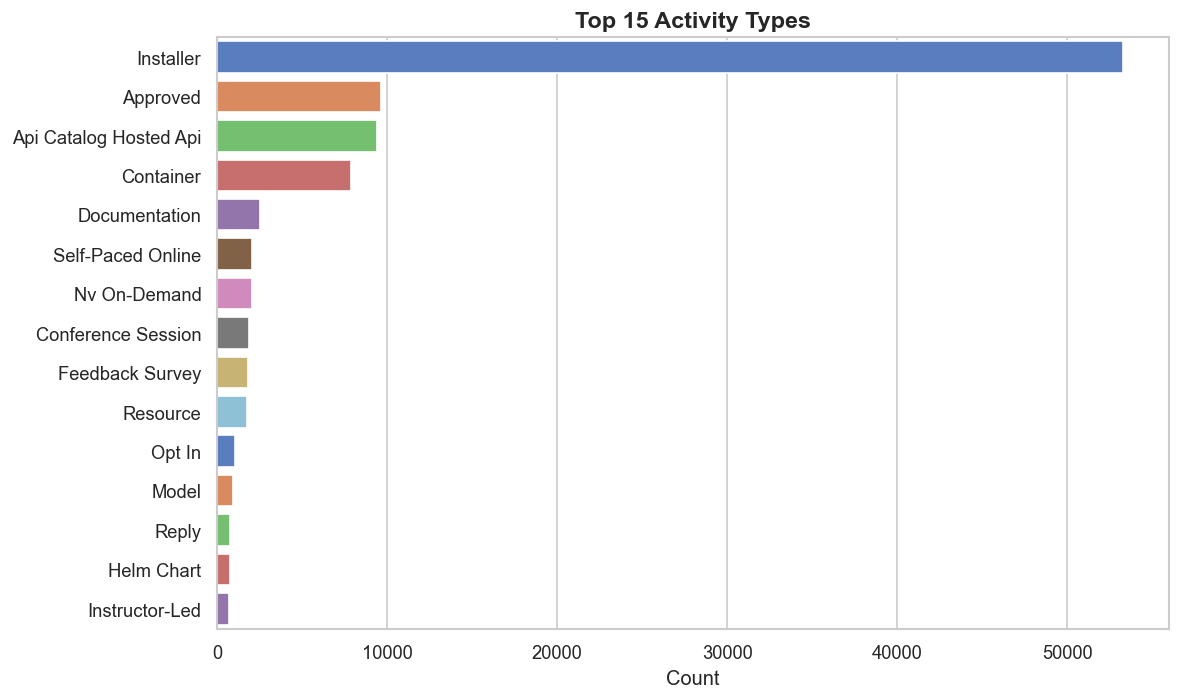

activity_type
Installer                 53298
Approved                   9637
Api Catalog Hosted Api     9404
Container                  7865
Documentation              2497
Self-Paced Online          2035
Nv On-Demand               2020
Conference Session         1865
Feedback Survey            1828
Resource                   1758
Opt In                     1045
Model                       958
Reply                       732
Helm Chart                  724
Instructor-Led              671
Name: count, dtype: int64


In [77]:
type_counts = activity_df['activity_type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=type_counts.values, y=type_counts.index, palette='muted', ax=ax)
ax.set_title('Top 15 Activity Types', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(type_counts)

Activity Score Distribution

In [78]:
scores = activity_df['activity_score'].dropna()
print('Score stats:')
print(scores.describe())
print('Zero scores:', (scores == 0).sum())
print('Null scores:', activity_df['activity_score'].isnull().sum())

Score stats:
count    98710.000000
mean         3.413139
std          4.589655
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max        100.000000
Name: activity_score, dtype: float64
Zero scores: 10592
Null scores: 1290


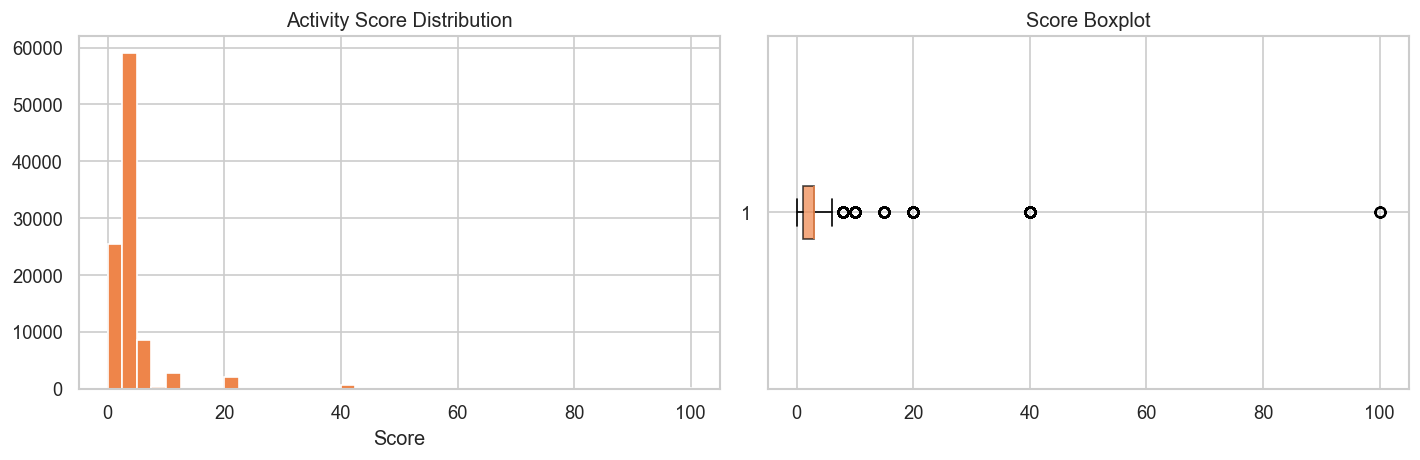

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(scores, bins=40, color=sns.color_palette('muted')[1], edgecolor='white')
axes[0].set_title('Activity Score Distribution')
axes[0].set_xlabel('Score')
axes[1].boxplot(scores, vert=False, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[1], alpha=0.7))
axes[1].set_title('Score Boxplot')
plt.tight_layout()
plt.show()

Interpretation:
- majority of developer activities have low engagement scores, but a small group of highly engaged developers are pulling the distribution out to the right
- shows long-tail engagement pattern: most people do low-value activities (maybe just registering or clicking a link), while a few highely engaged users get high scores through deep participation

Developer Engagement Depth

In [80]:
dev_activity = activity_df.groupby('dev_contact').agg(
    total_activities = ('activity_id', 'count'),
    unique_types     = ('activity_type', 'nunique'),
    avg_score        = ('activity_score', 'mean'),
    total_score      = ('activity_score', 'sum'),
    first_activity   = ('activity_date', 'min'),
    last_activity    = ('activity_date', 'max')
).reset_index()

dev_activity['days_active_span'] = (
    dev_activity['last_activity'] - dev_activity['first_activity']
).dt.days

print('Developer engagement summary:')
display(dev_activity.describe())

Developer engagement summary:


,total_activities,unique_types,avg_score,total_score,first_activity,last_activity,days_active_span
count,80054.000000,80054.000000,79141.000000,80054.000000,79711,79711,79711.000000
mean,1.249157,1.026270,3.434093,4.208547,2023-06-08 13:58:01.302354688,2023-07-08 17:00:00.706489600,30.124751
min,1.000000,1.000000,0.000000,0.000000,2020-01-01 00:00:00,2020-01-01 00:00:00,0.000000
25%,1.000000,1.000000,1.000000,1.000000,2021-10-08 00:00:00,2021-11-21 00:00:00,0.000000
50%,1.000000,1.000000,3.000000,3.000000,2023-07-16 00:00:00,2023-09-05 00:00:00,0.000000
75%,1.000000,1.000000,3.000000,3.000000,2025-03-10 00:00:00,2025-03-20 00:00:00,0.000000
max,2945.000000,6.000000,100.000000,14556.000000,2026-03-12 15:56:17,2026-03-12 15:56:17,2222.000000
std,11.307903,0.187213,4.925011,55.867743,NaN,NaN,156.796329


In [82]:
# Top tier users
threshold = dev_activity['total_activities'].quantile(0.9)
top_users = dev_activity[dev_activity['total_activities'] >= threshold]
print(f'Top 10% engagement threshold: {threshold:.0f} activities')
print(f'Top users: {len(top_users)}')

Top 10% engagement threshold: 2 activities
Top users: 8299


Engagement by role

<positron-console-cell-83>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<positron-console-cell-83>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



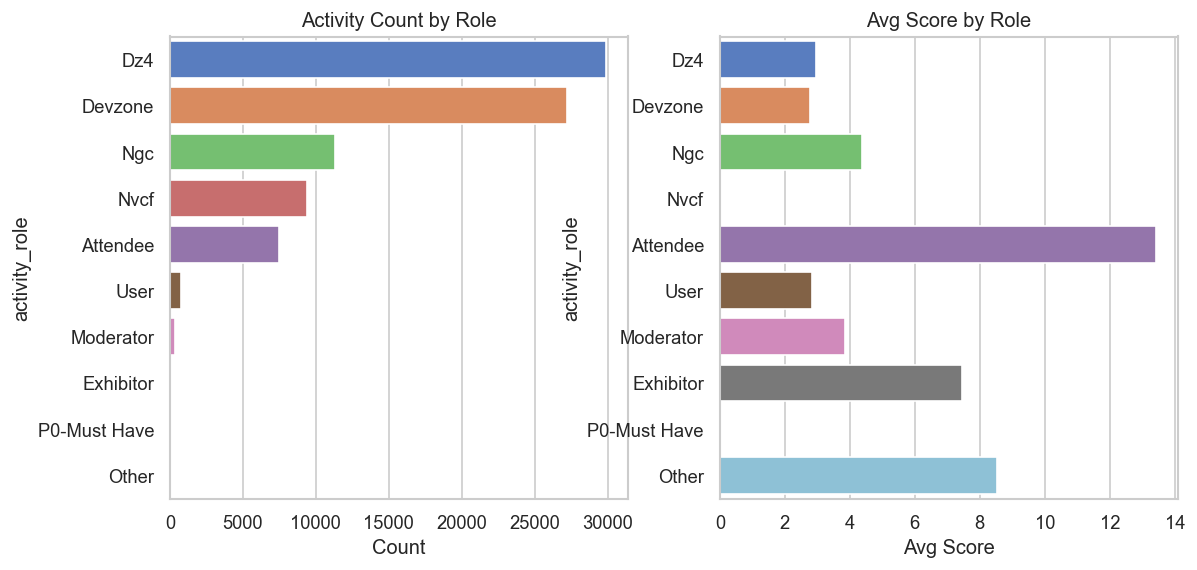

In [83]:
role_stats = (activity_df[activity_df['activity_role'].str.strip().str.lower() != 'nan']
    .groupby('activity_role').agg(
        count     = ('activity_id', 'count'),
        avg_score = ('activity_score', 'mean')
    ).sort_values('count', ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=role_stats['count'], y=role_stats.index, palette='muted', ax=axes[0])
axes[0].set_title('Activity Count by Role')
axes[0].set_xlabel('Count')

sns.barplot(x=role_stats['avg_score'], y=role_stats.index, palette='muted', ax=axes[1])
axes[1].set_title('Avg Score by Role')
axes[1].set_xlabel('Avg Score')

plt.subplots_adjust(left=0.3)
plt.show()

Attendance Analysis

In [84]:
# Score by attendance
att_score = (activity_df[activity_df['activity_attendance'].str.strip().str.lower() != 'true'] #omit 'true' 
             .groupby('activity_attendance')['activity_score']
             .mean()
             .sort_values(ascending=False))
print('Avg score by attendance status:')
print(att_score)

Avg score by attendance status:
activity_attendance
Attended Live                                  24.816984
Attended Live;Registered                       10.462295
Attended Live;Registered;Waitlisted            10.000000
Waitlisted;Attended Live;Registered            10.000000
Registered; Attended Live                      10.000000
Registered;Attended Live                        9.176471
Attended On-Demand;Registered                   3.802111
Attended On-Demand;Attended Live;Registered     3.000000
Attended On-Demand                              3.000000
Attended Live;Registered;Attended On-Demand     3.000000
Attended Live;Attended On-Demand;Registered     3.000000
Attended On-Demand;Registered;Attended Live     3.000000
Registered;Attended Live;Attended On-Demand     3.000000
Registered;Attended On-Demand                   3.000000
Registered;Attended On-Demand;Attended Live     3.000000
Name: activity_score, dtype: float64


Attendance value counts:
activity_attendance
Attended Live                                  2733
Attended Live;Registered                       2440
Attended On-Demand;Registered                  1913
Registered;Attended On-Demand                   249
Registered; Attended Live                       175
Registered;Attended Live                         68
Attended Live;Attended On-Demand;Registered      27
Attended On-Demand                               25
Attended On-Demand;Attended Live;Registered       4
Registered;Attended On-Demand;Attended Live       2
Attended On-Demand;Registered;Attended Live       2
Registered;Attended Live;Attended On-Demand       1
Waitlisted;Attended Live;Registered               1
Attended Live;Registered;Attended On-Demand       1
Attended Live;Registered;Waitlisted               1
Name: count, dtype: int64


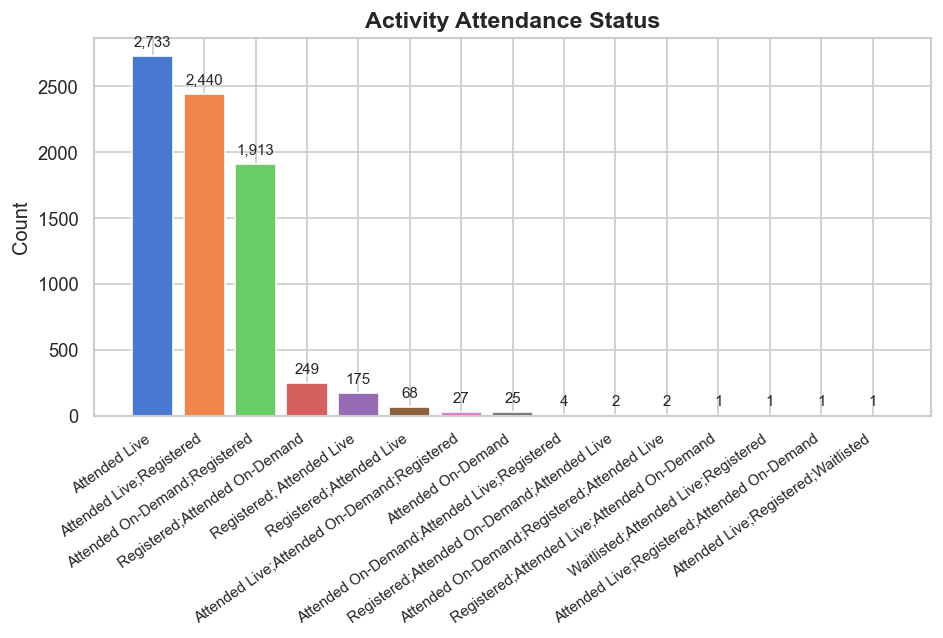

In [85]:
if 'activity_attendance' in activity_df.columns:
    att_counts = activity_df['activity_attendance'].value_counts()
    att_counts = att_counts[att_counts.index.str.strip().str.lower() != 'true'] #Filtered out 'true' ~10.8k 
    
    print('Attendance value counts:')
    print(att_counts)
    
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(range(len(att_counts)), att_counts.values, 
                  color=sns.color_palette('muted'), edgecolor='white')
    
    # Add count labels on top of each bar
    for bar, val in zip(bars, att_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(range(len(att_counts)))
    ax.set_xticklabels(att_counts.index, rotation=35, ha='right', fontsize=9)
    ax.set_title('Activity Attendance Status', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    plt.subplots_adjust(bottom=0.25) 
    plt.show()

Lead Source Analysis

In [86]:
lead_counts = (activity_df['lead_source']
               .dropna()
               .loc[lambda x: x.str.strip().str.lower() != 'nan']
               .value_counts()
               .head(15)
               .sort_values(ascending=True))

excluded 82.9k Nan

In [87]:
print('Top 15 Lead Sources:')
print(lead_counts.sort_values(ascending=False))

Top 15 Lead Sources:
lead_source
Gseo                                                                               6231
Website                                                                            4525
Ref                                                                                4353
Bseo                                                                               1486
Yseo                                                                                 24
Nala_Dev_Wbn_202311_Dl28_The Fast Path To Developing With Llms                       23
Nala_Dev_Wbn_202311_Dl28_Tailoring Llms To Your Use Case                             12
Emea_Dev_Wbn_202510_Nvt01_How To Prepare For Nvidia Generative Ai Certification      10
Nala_Dev_Wbn_202311_Dl28_Llm And Generative Ai For Life Sciences                     10
Emea_Dev_Wbn_Nvt01_Get Ready For Ai Infrastructure Certification                      8
Apac_Dev_Wbn_202501_Dev03_Accelerating Python On Gpus                                 8

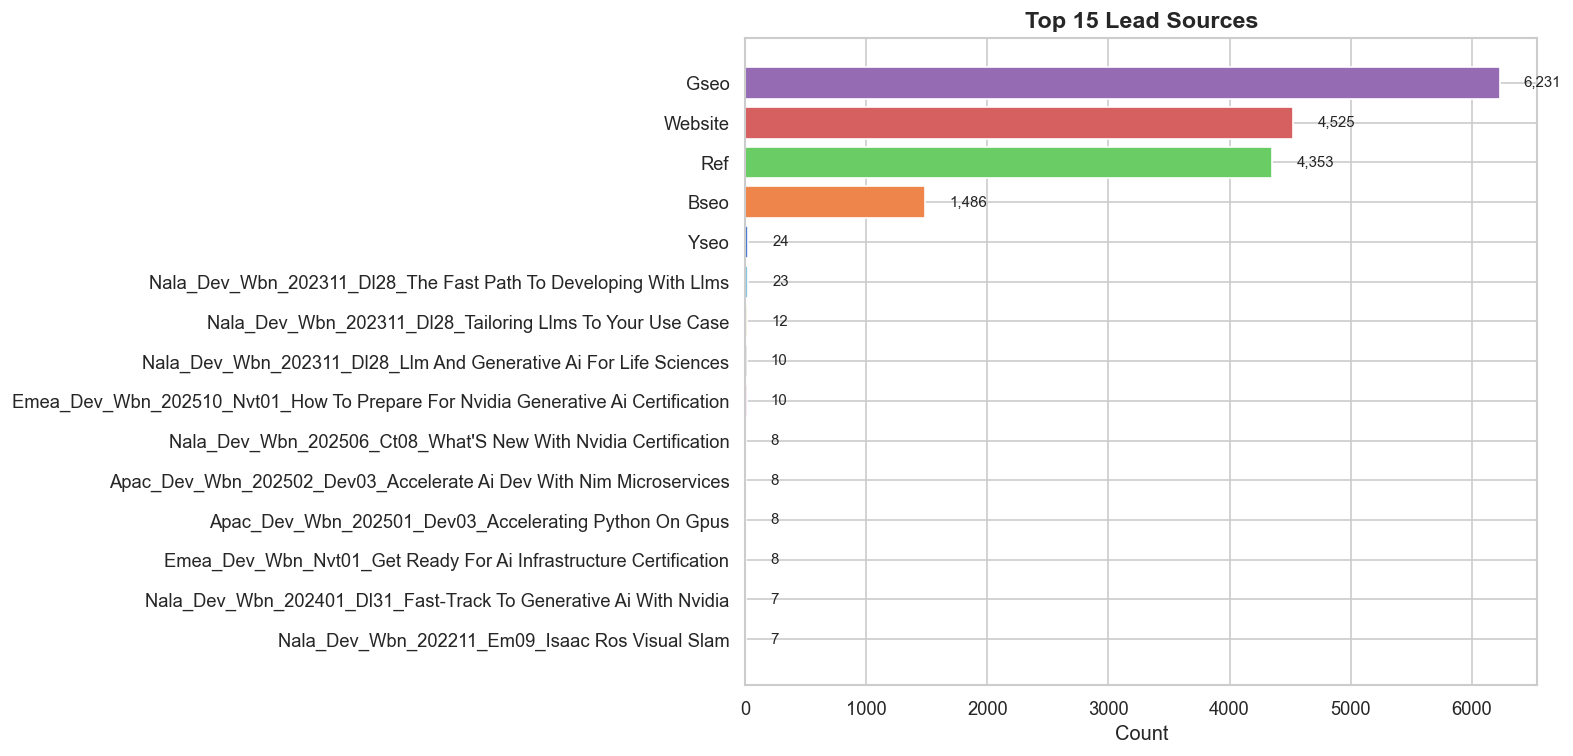

In [88]:
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(lead_counts.index, lead_counts.values,  # pass index directly, not range()
               color=sns.color_palette('muted', len(lead_counts)), edgecolor='white')

# Count labels at end of each bar
for bar, val in zip(bars, lead_counts.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 15 Lead Sources', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.subplots_adjust(left=0.3)
plt.show()

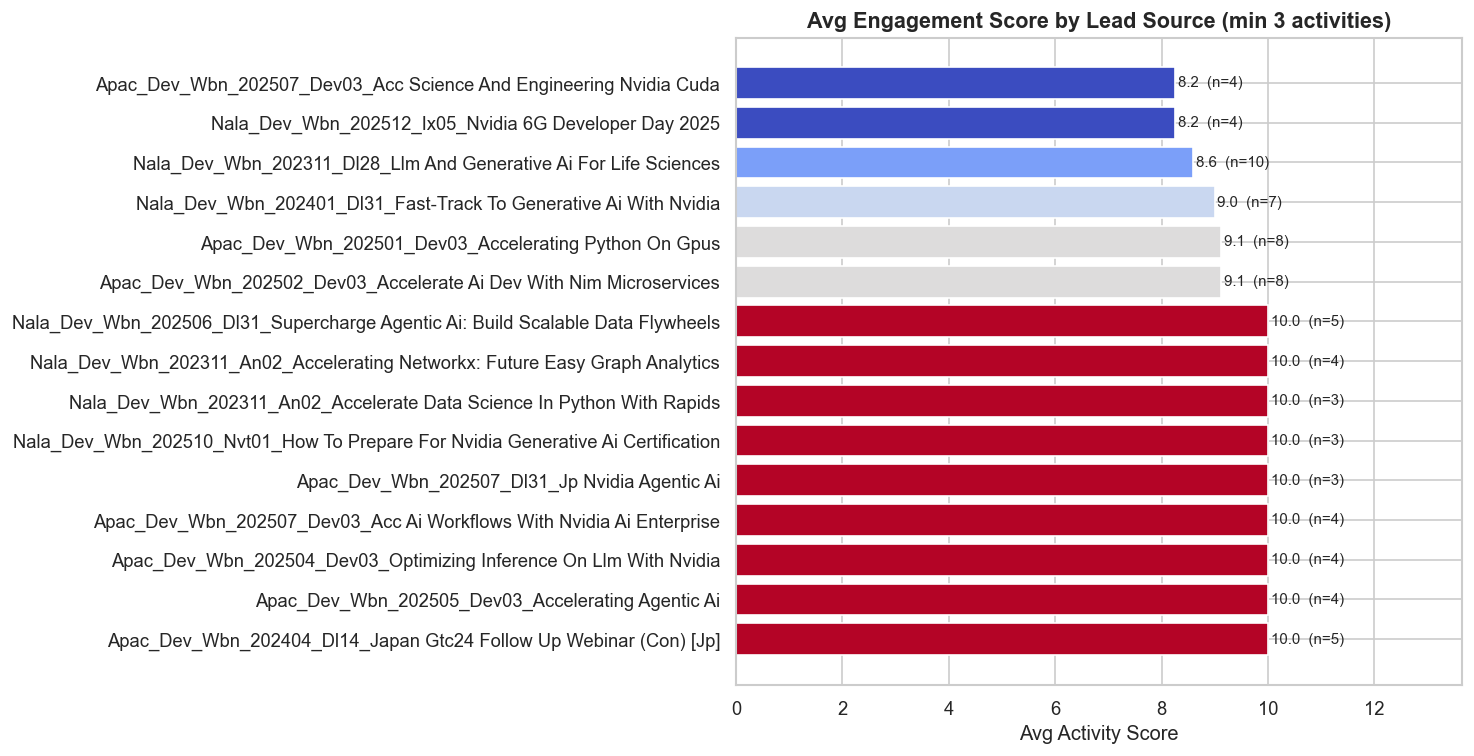

In [89]:
# Lead source engagement quality: avg score per source
lead_quality = (activity_df[activity_df['lead_source'].str.strip().str.lower() != 'nan'] # Filter out Nan
    .groupby('lead_source').agg(
        count     = ('activity_id', 'count'),
        avg_score = ('activity_score', 'mean')
    ).query('count >= 3') # Can change minimum activities ** 
    .sort_values('avg_score', ascending=False)
    .head(15))
    
fig, ax = plt.subplots(figsize=(11, 7))

norm = plt.Normalize(lead_quality['avg_score'].min(), lead_quality['avg_score'].max())
colors = plt.cm.coolwarm(norm(lead_quality['avg_score']))

bars = ax.barh(lead_quality.index, lead_quality['avg_score'],
               color=colors, edgecolor='white')

# Add avg score + count label on each bar
for bar, (_, row) in zip(bars, lead_quality.iterrows()):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'{row["avg_score"]:.1f}  (n={int(row["count"]):,})',
            va='center', fontsize=9)

ax.set_title('Avg Engagement Score by Lead Source (min 3 activities)', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Activity Score')
ax.set_xlim(0, ax.get_xlim()[1] * 1.3)
ax.set_ylabel('')
plt.subplots_adjust(left=0.35)
plt.show()

Campaign Analysis

In [90]:
# Top campaigns by activity volume
campaign_vol = activity_df['nvidia_campaign_id'].value_counts().head(20)
print('Top 20 campaigns by activity count:')
print(campaign_vol)

Top 20 campaigns by activity count:
nvidia_campaign_id
no-ncid                    101
ref-dev-557858              39
em-nurt-420552-vt33         23
PMCF NCID                   16
progr-120708-vt33           14
afm-chs-44270               12
em-news-525732              11
em-nurt-245273-vt33         11
https://www.google.com/     11
pa-srch-baid-450176         10
so-wech-293145               9
ref-dev-500409               8
em-nurt-331245               8
em-nurt-90067                7
em-nurt-724265               7
em-even-124008-vt33          6
em-anno-316003               6
em-webi-146394-vt16          6
em-even-800877               6
pa-srch-goog-740190          6
Name: count, dtype: int64


In [91]:
# Campaigns with highest avg score
campaign_quality = activity_df.groupby('nvidia_campaign_id').agg(
    count     = ('activity_id', 'count'),
    avg_score = ('activity_score', 'mean')
).query('count >= 30').sort_values('avg_score', ascending=False).head(10)

print('Top 10 campaigns by avg score (min 30 activities):')
display(campaign_quality)

Top 10 campaigns by avg score (min 30 activities):


,count,avg_score
nvidia_campaign_id,,
no-ncid,101,5.871287
ref-dev-557858,39,1.000000


General

In [92]:
print(f"Total activities:          {len(activity_df):,}")
print(f"Unique developers:         {activity_df['dev_contact'].nunique():,}")
print(f"Date range:                {activity_df['activity_date'].min().date()} → {activity_df['activity_date'].max().date()}")
print(f"Unique activity types:     {activity_df['activity_type'].nunique()}")
print(f"Unique lead sources:       {activity_df['lead_source'].nunique()}")
print(f"Unique campaigns:          {activity_df['nvidia_campaign_id'].nunique()}")
print(f"Avg score overall:         {activity_df['activity_score'].mean():.2f}")
print(f"Median activities/dev:     {dev_activity['total_activities'].median():.0f}")
print(f"Threshold (90th percentile): {dev_activity['total_activities'].quantile(0.9):.0f} activities")

Total activities:          100,000
Unique developers:         80,054
Date range:                2020-01-01 → 2026-03-12
Unique activity types:     48
Unique lead sources:       169
Unique campaigns:          542
Avg score overall:         3.41
Median activities/dev:     1
Threshold (90th percentile): 2 activities
